# Task 1: Translation and Rotation 

Homogeneous 3x3 matrices and `cv2.warpPerspective` to shift and rotate a scan.

## Imports & Load Image

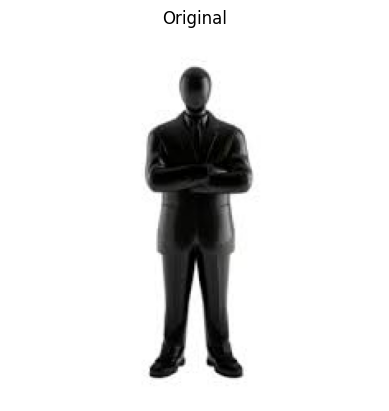

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../CVLab01/assets/image.jpg')
h, w = img.shape[:2]

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off'); plt.show()


## Translation

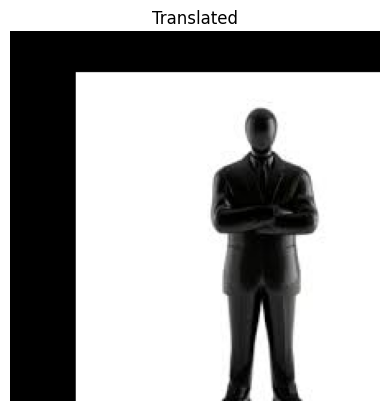

In [2]:
tx, ty = 40, 25
T = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=np.float32)
translated = cv2.warpPerspective(img, T, (w, h))

plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)); plt.title('Translated'); plt.axis('off'); plt.show()


## Rotation about center

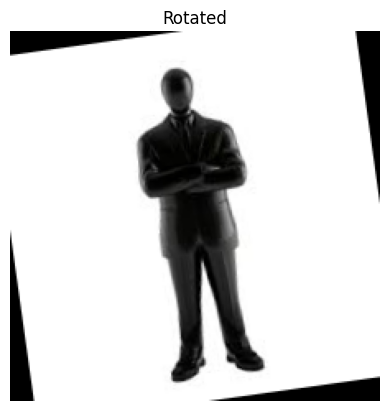

In [3]:
angle_deg = -8
theta = np.radians(angle_deg)
c, s = np.cos(theta), np.sin(theta)
cx, cy = w / 2, h / 2
R = np.array([
    [c, -s, cx - c * cx + s * cy],
    [s,  c, cy - s * cx - c * cy],
    [0,  0,  1],
], dtype=np.float32)
rotated = cv2.warpPerspective(img, R, (w, h))

plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)); plt.title('Rotated'); plt.axis('off'); plt.show()


## Combined: translate then rotate

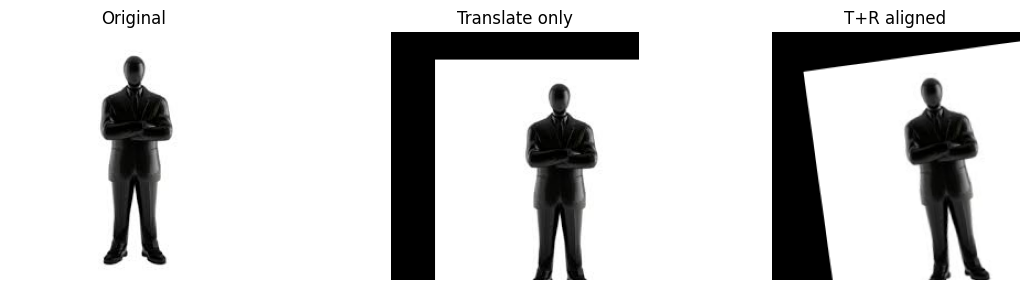

In [4]:
M = R @ T  # first T, then R on the point
aligned = cv2.warpPerspective(img, M, (w, h))

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, im, t in zip(ax, [img, translated, aligned], ['Original', 'Translate only', 'T+R aligned']):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()
